# Project: The Dark Pattern Tax: Exposing Manufactured Discounts on Flipkart

* **Tools:** Python | Pandas | Matplotlib
* **Data:** Flipkart Products Dataset — 20,000 real product listings (PromptCloud via Kaggle)
* **Objective:** Investigate whether Flipkart discounts are genuine or systematically engineered through artificial inflation of Maximum Retail Price (MRP).



## Business Context

India's e-commerce market runs on one core psychological lever: the discount.
Platforms like Flipkart display large MRP prices alongside heavily slashed
selling prices — training consumers to evaluate value through the discount
percentage rather than the actual price.

But MRP in India is self-declared by sellers. There is no enforcement
mechanism ensuring the MRP reflects what the product ever actually sold for.
This creates a systemic opportunity for price manipulation — inflate the MRP,
apply a large discount, sell at the original intended price while the consumer
feels they won.

**The Research Question:**
Are Flipkart discounts genuine reductions from real market prices —
or are they manufactured through MRP inflation?

**Stakeholders:**
- Consumers: misled into purchases based on false savings perception
- Flipkart: long-term reputational and retention risk if trust erodes
- Sellers: incentivised to inflate MRP to compete on discount % optics
- CCPA (Consumer protection regulator): responsible for enforcing fair pricing

**Key Metrics I Will Quantify:**
1. Discount Engineering Index — how concentrated are discounts at round numbers vs what randomness would predict
2. MRP Inflation Ratio — how much is retail price inflated above selling price per category
3. Phantom Savings — the rupee value of savings that were never real
4. Consumer Harm Score — a weighted index combining all three signals per category

**Hypothesis:**
Discount percentages on Flipkart are systematically engineered —
particularly in fashion and jewellery categories — and higher discounts
correlate with lower product quality, suggesting markdowns are used
to clear unsold inventory rather than pass genuine savings to consumers.

**Consumer Recommendation:**
Always verify price history on tools like PriceSpy or Smartprix before
purchasing during sale events. The discount percentage is the least
reliable signal of actual value.

## Table of Contents

1. Business Context
2. Data Overview & Cleaning
3. Analysis 1 — Discount Engineering Test
4. Analysis 2 — MRP Inflation Quantification
5. Analysis 3 — Phantom Savings Calculation
6. Analysis 4 — Consumer Harm Score
7. Visualizations
8. Business Implications & Recommendations

In [4]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

In [5]:
from google.colab import files
uploaded = files.upload()

Saving flipkart_com-ecommerce_sample.csv to flipkart_com-ecommerce_sample.csv


In [6]:
df = pd.read_csv("flipkart_com-ecommerce_sample.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst row preview:")
df.head(2)

Shape: (20000, 15)

Columns:
 ['uniq_id', 'crawl_timestamp', 'product_url', 'product_name', 'product_category_tree', 'pid', 'retail_price', 'discounted_price', 'image', 'is_FK_Advantage_product', 'description', 'product_rating', 'overall_rating', 'brand', 'product_specifications']

First row preview:


,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."


In [7]:
print("Null counts:\n")
print(df.isnull().sum())

Null counts:

uniq_id                       0
crawl_timestamp               0
product_url                   0
product_name                  0
product_category_tree         0
pid                           0
retail_price                 78
discounted_price             78
image                         3
is_FK_Advantage_product       0
description                   2
product_rating                0
overall_rating                0
brand                      5864
product_specifications       14
dtype: int64


In [8]:
df = df.dropna(subset=["retail_price", "discounted_price"])
print("After dropping price nulls:", df.shape)

df["discount_pct"] = (
    (df["retail_price"] - df["discounted_price"]) / df["retail_price"] * 100
).round(1)

print("\nDiscount % stats:")
print(df["discount_pct"].describe())


After dropping price nulls: (19922, 15)

Discount % stats:
count    19922.000000
mean        40.524285
std         23.548116
min          0.000000
25%         21.100000
50%         45.000000
75%         60.000000
max         96.500000
Name: discount_pct, dtype: float64


In [9]:
print("Before cleaning - sample values:")
print(df["product_rating"].unique()[:8])

df["rating"] = pd.to_numeric(df["product_rating"], errors="coerce")

print("\nAfter cleaning:")
print(f"Products WITH ratings: {df['rating'].notna().sum():,}")
print(f"Products WITHOUT ratings: {df['rating'].isna().sum():,}")
print("\nRating stats:")
print(df["rating"].describe())

Before cleaning - sample values:
['No rating available' '5' '3' '3.6' '3.5' '4.4' '4' '1']

After cleaning:
Products WITH ratings: 1,839
Products WITHOUT ratings: 18,083

Rating stats:
count    1839.000000
mean        3.810332
std         1.260124
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: rating, dtype: float64


In [10]:
print("Raw category sample:")
print(df["product_category_tree"].iloc[0])
print()

df["category"] = df["product_category_tree"].str.extract(r'\["(.+?) >>')[0]

print("Cleaned category sample:")
print(df["category"].value_counts().head(10))

Raw category sample:
["Clothing >> Women's Clothing >> Lingerie, Sleep & Swimwear >> Shorts >> Alisha Shorts >> Alisha Solid Women's Cycling Shorts"]

Cleaned category sample:
category
Clothing                      6171
Jewellery                     3522
Footwear                      1225
Mobiles & Accessories         1097
Automotive                    1010
Home Decor & Festive Needs     927
Beauty and Personal Care       709
Home Furnishing                700
Kitchen & Dining               645
Computers                      573
Name: count, dtype: int64


In [11]:
df_disc = df[df["discount_pct"] > 0].copy()

print(f"Total products: {len(df):,}")
print(f"Products with discount > 0%: {len(df_disc):,}")
print(f"Products with discount ≥ 50%: {(df_disc['discount_pct'] >= 50).sum():,}")
print(f"That's {(df_disc['discount_pct'] >= 50).mean()*100:.1f}% of all discounted products")

Total products: 19,922
Products with discount > 0%: 17,635
Products with discount ≥ 50%: 9,164
That's 52.0% of all discounted products


In [13]:
# Analysis 1: Discount Engineering Test
discount_counts = (df_disc["discount_pct"]
                   .value_counts()
                   .reset_index()
                   .rename(columns={"discount_pct": "discount_pct",
                                    "count": "product_count"})
                   .sort_values("discount_pct"))

discount_counts["is_round"] = discount_counts["discount_pct"] % 10 == 0

round_summary = (discount_counts
                 .groupby("is_round")["product_count"]
                 .sum()
                 .reset_index())

total = discount_counts["product_count"].sum()
actual_round_pct   = round_summary[round_summary["is_round"] == True]["product_count"].values[0] / total * 100
expected_round_pct = 10.0  # in a truly random distribution

print("Discount Engineering Test")
print(f"Expected round-number concentration (random): {expected_round_pct:.1f}%")
print(f"Actual round-number concentration:            {actual_round_pct:.1f}%")
print(f"Overrepresentation factor:                    {actual_round_pct/expected_round_pct:.1f}x")
print(f"\nTop 10 most common discount values:")
print(discount_counts.sort_values("product_count", ascending=False).head(10))

Discount Engineering Test
Expected round-number concentration (random): 10.0%
Actual round-number concentration:            15.3%
Overrepresentation factor:                    1.5x

Top 10 most common discount values:
   discount_pct  product_count  is_round
0          50.1            807     False
1          50.0            790      True
2          40.0            434      True
3          20.0            425      True
4          60.1            366     False
5          30.0            335      True
6          33.4            283     False
7          67.4            271     False
8          60.0            265      True
9          72.8            250     False


### Finding 1 — Discount Engineering Test

**What the data shows:**
15.3% of discounted products on Flipkart have round-number discount
percentages (10%, 20%, 30%, 40%, 50% etc.) — compared to a 10% baseline
expectation under truly random, cost-driven pricing.

This represents a **1.53x overrepresentation** across 17,000+ products.

**What this means:**
In organic pricing, a seller calculates cost → adds margin → arrives at
selling price → MRP is set slightly above that. This process produces
irregular discount percentages like 13.7%, 27.4%, 42.1%.

Round number discounts (exactly 50%, exactly 40%) suggest the reverse
process: the seller decided the discount first, then set the MRP backwards
to achieve it. The product was never going to sell at that MRP.

**Limitation:**
15.3% is a moderate signal — not conclusive proof on its own.
This finding gains strength when combined with the MRP inflation
and phantom savings analyses that follow.

In [19]:
#Analysis 2: MRP Inflation Quantification

df_disc["inflation_ratio"] = (df_disc["retail_price"] /
                               df_disc["discounted_price"]).round(2)

# Flag confirmed inflation (MRP > 2x selling price)
df_disc["confirmed_inflation"] = df_disc["inflation_ratio"] >= 2.0

# Category-wise inflation profile
inflation_index = (df_disc
                   .groupby("category")
                   .agg(
                       avg_inflation    = ("inflation_ratio", "mean"),
                       max_inflation    = ("inflation_ratio", "max"),
                       confirmed_count  = ("confirmed_inflation", "sum"),
                       total_products   = ("inflation_ratio", "count"),
                   )
                   .round(2)
                   .reset_index())

inflation_index["confirmed_pct"] = (
    inflation_index["confirmed_count"] /
    inflation_index["total_products"] * 100
).round(1)

inflation_index = (inflation_index
                   .sort_values("avg_inflation", ascending=False)
                   .reset_index(drop=True))

print("MRP Inflation Index by Category")
print(inflation_index[["category", "avg_inflation",
                        "confirmed_count", "confirmed_pct"]].head(10))

MRP Inflation Index by Category
                            category  avg_inflation  confirmed_count  \
0                         Sunglasses           3.04               25   
1              Mobiles & Accessories           2.51              658   
2                            Eyewear           2.51                3   
3                         Automotive           2.50              680   
4  Health & Personal Care Appliances           2.48               14   
5                             Gaming           2.46               23   
6              Bags, Wallets & Belts           2.41              169   
7             Wearable Smart Devices           2.34                2   
8                            Watches           2.34              116   
9                           Clothing           2.34             3627   

   confirmed_pct  
0           71.4  
1           61.0  
2           30.0  
3           68.3  
4           48.3  
5           67.6  
6           69.5  
7          100.0  
8   

### Finding 2a — MRP Inflation Index by Category

MRP inflation ratio measures how much the listed MRP exceeds the actual
selling price. A ratio of 2.0 means the consumer is shown a price **double
what the product actually sells for** — identifying how aggressively
each category manufactures discount perception.

**Sunglasses lead with 3.04x avg inflation** — 71.4% of products have
MRP set more than 2x above selling price. A ₹300 sunglass is routinely
listed at ₹900 MRP to manufacture a "67% off" perception.

**Clothing has the highest confirmed count at 3,627 products (66.7%)** —
making it the category where MRP inflation affects the most consumers
at scale, despite a lower average ratio than Sunglasses.

**Mobiles & Accessories (2.51x, 658 confirmed products)** sits at the
intersection of high inflation and high consumer trust — the most
dangerous combination for platform credibility.

In [21]:
worst_offender = (df_disc
                  .loc[df_disc.groupby("category")["inflation_ratio"].idxmax(),
                       ["category", "retail_price",
                        "discounted_price", "inflation_ratio"]]
                  .sort_values("inflation_ratio", ascending=False)
                  .head(5)
                  .reset_index(drop=True))

worst_offender["example"] = (
    "MRP ₹" + worst_offender["retail_price"].astype(int).astype(str) +
    " → Selling ₹" + worst_offender["discounted_price"].astype(int).astype(str)
)

print(worst_offender[["category", "inflation_ratio", "example"]])

                   category  inflation_ratio                     example
0           Home Furnishing            28.85    MRP ₹6000 → Selling ₹208
1                 Jewellery            21.16    MRP ₹3999 → Selling ₹189
2     Mobiles & Accessories            18.34     MRP ₹1816 → Selling ₹99
3                 Computers            13.32      MRP ₹999 → Selling ₹75
4  Beauty and Personal Care            12.43  MRP ₹21125 → Selling ₹1700


### Finding 2b — Worst Offender: Maximum MRP Inflation

MRP in India is **self-declared by sellers** with no enforcement mechanism —
this analysis identifies categories where that freedom is most exploited.

**Home Furnishing shows a peak inflation ratio of 28.85x** — a single product
listed at MRP nearly 29 times its actual selling price. A consumer seeing
"97% off" would rationally trust it as a clearance deal. It isn't.

**Mobiles & Accessories (18.34x) is the most concerning at scale** — consumers
inherently trust electronics pricing more than fashion. High inflation here
exploits that trust directly.

This analysis moves beyond averages — identifying the **ceiling of deception**
per category, which average inflation ratios alone would mask.

In [27]:
# Analysis 3: Phantom Savings Quantification

# "Phantom savings" = the discount amount shown to the consumer
# But if MRP is inflated, a portion of that "saving" was never real

# Genuine saving  = max(0, fair_price - discounted_price)
# Phantom saving  = discount_shown - genuine_saving

# estimate fair_price as: discounted_price * 1.15
# (assuming a 15% genuine margin is reasonable for most categories)
# Everything above that in the MRP is manufactured

FAIR_MARGIN = 0.15

df_disc["fair_price"]      = (df_disc["discounted_price"] * (1 + FAIR_MARGIN)).round(2)
df_disc["discount_shown"]  = df_disc["retail_price"] - df_disc["discounted_price"]
df_disc["genuine_saving"]  = (df_disc["fair_price"] - df_disc["discounted_price"]).clip(lower=0)
df_disc["phantom_saving"]  = (df_disc["discount_shown"] - df_disc["genuine_saving"]).clip(lower=0)
df_disc["phantom_pct"]     = (df_disc["phantom_saving"] /
                               df_disc["discount_shown"].replace(0, np.nan) * 100).round(1)

# Category-wise phantom savings summary
phantom_summary = (df_disc
                   .groupby("category")
                   .agg(
                       avg_phantom_saving  = ("phantom_saving", "mean"),
                       total_phantom_value = ("phantom_saving", "sum"),
                       avg_phantom_pct     = ("phantom_pct", "mean"),
                       product_count       = ("phantom_saving", "count")
                   )
                   .round(2)
                   .sort_values("avg_phantom_saving", ascending=False)
                   .reset_index())

print("Phantom Savings by Category")
print(phantom_summary[["category", "avg_phantom_saving",
                        "avg_phantom_pct", "product_count"]].head(10))
print(f"\nTotal phantom savings across dataset: ₹{df_disc['phantom_saving'].sum():,.0f}")
print(f"Average phantom saving per product:   ₹{df_disc['phantom_saving'].mean():,.0f}")
print(f"\nScaled estimate (Flipkart ~100M listings): "
      f"₹{df_disc['phantom_saving'].mean() * 100_000_000 / 1_00_00_000:,.0f} crore in phantom savings")

Phantom Savings by Category
                     category  avg_phantom_saving  avg_phantom_pct  \
0                   Furniture             5605.13            69.08   
1                  Automotive             1565.41            84.00   
2                   Jewellery             1410.58            69.20   
3       Bags, Wallets & Belts              964.36            81.12   
4                   Computers              949.70            74.85   
5                     Eyewear              826.99            71.53   
6          Home Entertainment              799.20            68.50   
7  Home Decor & Festive Needs              783.44            67.49   
8              Home & Kitchen              757.29            66.34   
9       Mobiles & Accessories              744.17            76.84   

   product_count  
0            141  
1            996  
2           3284  
3            243  
4            544  
5             10  
6             17  
7            860  
8             19  
9          

### Finding 3 — Phantom Savings Quantification

Phantom savings measure the portion of displayed discount that was never
real — manufactured purely through MRP inflation. This answers the question
**"how much of what I think I saved did I actually save?"**

**Furniture shows the highest avg phantom saving at ₹5,605 per product** —
a consumer buying a sofa believing they saved ₹8,000 may have genuinely
saved only ₹2,400. The rest was perception engineered through MRP inflation.

**Automotive is the most deceptive by ratio — 84% phantom** — meaning
84 paise of every ₹1 shown as discount in this category is manufactured.
Only 16 paise reflects genuine price reduction.

**Jewellery affects the most consumers at scale** — ₹1,410 avg phantom
saving across 3,284 products, making it the highest total consumer
deception by volume.

**Across the full dataset: ₹1.51 crore in phantom savings displayed
to consumers — against just 20,000 products.** Scaled to Flipkart's
full catalogue of millions of listings, the platform-wide phantom
savings figure runs into thousands of crores annually.

**Scaled Projection (Illustrative):**
Applying the dataset avg of ₹857 phantom saving per product to Flipkart's
estimated 100M+ active listings suggests a **platform-wide phantom savings
figure of ~₹8,570 crore annually.**

*Note: This is an illustrative extrapolation assuming similar pricing
patterns hold across the full catalogue. Actual figures would require
complete platform data — but the directional magnitude is significant.*

In [29]:
# Analysis 4: Quality Trap Analysis

df_rated = df_disc[df_disc["rating"].notna()].copy()

# Bin products into discount bands
df_rated["discount_band"] = pd.cut(
    df_rated["discount_pct"],
    bins=[0, 30, 50, 70, 100],
    labels=["Low\n(<30%)", "Medium\n(30-50%)", "High\n(50-70%)", "Very High\n(>70%)"]
)

# Average rating per discount band
quality_trap = (df_rated
                .groupby("discount_band", observed=True)
                .agg(
                    avg_rating    = ("rating", "mean"),
                    median_rating = ("rating", "median"),
                    product_count = ("rating", "count")
                )
                .round(2)
                .reset_index())

# Correlation between discount % and rating
correlation = df_rated["discount_pct"].corr(df_rated["rating"]).round(3)

# Danger zone: high discount + low rating
danger_zone = df_rated[
    (df_rated["discount_pct"] >= 50) &
    (df_rated["rating"] < 3.5)
]

print("Quality Trap Analysis")
print(quality_trap)
print(f"\nCorrelation (discount% vs rating): r = {correlation}")
print(f"\nDanger Zone products (≥50% off, rating <3.5): {len(danger_zone):,}")
print(f"As % of rated products with ≥50% discount:    "
      f"{len(danger_zone)/len(df_rated[df_rated['discount_pct']>=50])*100:.1f}%")

Quality Trap Analysis
       discount_band  avg_rating  median_rating  product_count
0        Low\n(<30%)        3.76            4.0            408
1   Medium\n(30-50%)        3.74            4.0            417
2     High\n(50-70%)        3.92            4.2            555
3  Very High\n(>70%)        3.66            4.0            159

Correlation (discount% vs rating): r = 0.016

Danger Zone products (≥50% off, rating <3.5): 227
As % of rated products with ≥50% discount:    30.1%


### Finding 4 — Quality Trap Analysis

This analysis tests whether heavy discounts signal lower product quality —
a pattern that would indicate markdowns are used to clear poor inventory.

**Correlation between discount % and rating: r = 0.016 — effectively zero.**
Discount percentage carries no predictive power over product quality.
A consumer cannot use the size of a discount to infer whether a product
is good or bad.

**However, 30.1% of heavily discounted products (≥50% off) carry
below-average ratings** — meaning 1 in 3 deeply discounted products
is poor quality, even if the pattern isn't universal.

**The real finding: discount percentage is informationally useless
as a quality signal.** Consumers are making purchase decisions based
on a number that tells them nothing about what they're buying —
while being distracted from the metrics that actually matter:
ratings, reviews, and price history.

In [31]:
# Analysis 5: Consumer Harm Score (0-100)

# Weighted index combining 3 signals per category:
# 1. Round number concentration  → 30% weight
# 2. MRP inflation ratio         → 40% weight
# 3. Phantom saving %            → 30% weight

# Signal 1: round number concentration per category
round_by_cat = (df_disc
                .assign(is_round=df_disc["discount_pct"] % 10 == 0)
                .groupby("category")["is_round"]
                .mean()
                .reset_index()
                .rename(columns={"is_round": "round_concentration"}))

# Signal 2: avg inflation ratio per category (already computed)
inflation_signal = inflation_index[["category", "avg_inflation"]]

# Signal 3: avg phantom % per category (already computed)
phantom_signal = phantom_summary[["category", "avg_phantom_pct"]]

# Merge all signals
harm_df = (round_by_cat
           .merge(inflation_signal, on="category")
           .merge(phantom_signal,   on="category"))

# Normalise each signal to 0-100
def normalise(series):
    return ((series - series.min()) /
            (series.max() - series.min()) * 100).round(1)

harm_df["score_round"]    = normalise(harm_df["round_concentration"])
harm_df["score_inflation"]= normalise(harm_df["avg_inflation"])
harm_df["score_phantom"]  = normalise(harm_df["avg_phantom_pct"])

# Weighted final score
harm_df["consumer_harm_score"] = (
    harm_df["score_round"]     * 0.30 +
    harm_df["score_inflation"] * 0.40 +
    harm_df["score_phantom"]   * 0.30
).round(1)

harm_df = harm_df.sort_values("consumer_harm_score", ascending=False).reset_index(drop=True)

print("Consumer Harm Score by Category")
print(harm_df[["category", "consumer_harm_score",
               "score_round", "score_inflation", "score_phantom"]].head(10))

Consumer Harm Score by Category
                            category  consumer_harm_score  score_round  \
0                            Eyewear                 82.6        100.0   
1                         Sunglasses                 81.9         42.9   
2  Health & Personal Care Appliances                 67.1         43.1   
3                           Footwear                 66.0         81.3   
4                           Clothing                 65.4         44.0   
5              Bags, Wallets & Belts                 64.2         34.0   
6              Mobiles & Accessories                 59.9         17.8   
7                    Home Furnishing                 59.1         60.5   
8                         Automotive                 59.0          7.0   
9                             Gaming                 58.8         22.1   

   score_inflation  score_phantom  
0             72.3           78.8  
1            100.0           96.9  
2             70.7           86.3  
3        

### Finding 5 — Consumer Harm Score

The Consumer Harm Score (0-100) is a **weighted composite index** combining
three signals: round-number concentration (30%), MRP inflation ratio (40%),
and phantom savings % (30%). It ranks categories by their systematic
deception potential — not just one dimension of manipulation.

**Eyewear (82.6) and Sunglasses (81.9) are the highest-risk categories** —
driven by near-perfect round-number engineering and the highest MRP
inflation ratio in the dataset (3.04x avg). A consumer buying sunglasses
on Flipkart faces manipulation on every dimension simultaneously.

**Clothing (65.4) and Bags, Wallets & Belts (64.2) score high on phantom
savings** — these are high-volume categories, meaning the harm is not just
intense but widespread across the largest consumer base.

**Automotive scores 59.0 despite near-zero round-number engineering (7.0)** —
revealing that MRP inflation and phantom savings alone are sufficient
to cause significant consumer harm, even without discount engineering.

*Data note: Eyewear (10 products) and Sunglasses likely represent the
same category split at source — combined, they would represent the
single highest-risk category in the dataset.*

In [50]:
# Global Style

# Color Palette
ACCENT  = "#E63946"   # red   — dark pattern / danger
SAFE    = "#2A9D8F"   # teal  — genuine / good
GOLD    = "#E9C46A"   # yellow — highlights
PURPLE  = "#5A67D8"   # purple — neutral info
MID     = "#F4A261"   # orange — middle ground
BG_DARK = "#FFFFFF"   # background (white)
BG_MID  = "#F8F9FA"   # background mid (light grey)


plt.rcParams.update({
    # Background
    "figure.facecolor":  "#FFFFFF",
    "axes.facecolor":    "#F8F9FA",

    # Borders
    "axes.edgecolor":    "#CCCCCC",

    # Text
    "text.color":        "#1A1A2E",
    "axes.labelcolor":   "#1A1A2E",
    "xtick.color":       "#444444",
    "ytick.color":       "#444444",

    # Grid
    "grid.color":        "#DDDDDD",
    "grid.linewidth":    0.6,

    # Font
    "font.family":       "DejaVu Sans",

    # Spines
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

In [51]:
# Chart 1 Data Prep

# Separate round and non-round discount values
round_bars     = discount_counts[discount_counts["is_round"] == True]
non_round_bars = discount_counts[discount_counts["is_round"] == False]

print(f"Round number bins: {len(round_bars)}")
print(f"Non-round bins: {len(non_round_bars)}")
print(f"\nTop 5 round number spikes:")
print(round_bars.sort_values("product_count", ascending=False).head())

Round number bins: 9
Non-round bins: 851

Top 5 round number spikes:
   discount_pct  product_count  is_round
1          50.0            790      True
2          40.0            434      True
3          20.0            425      True
5          30.0            335      True
8          60.0            265      True


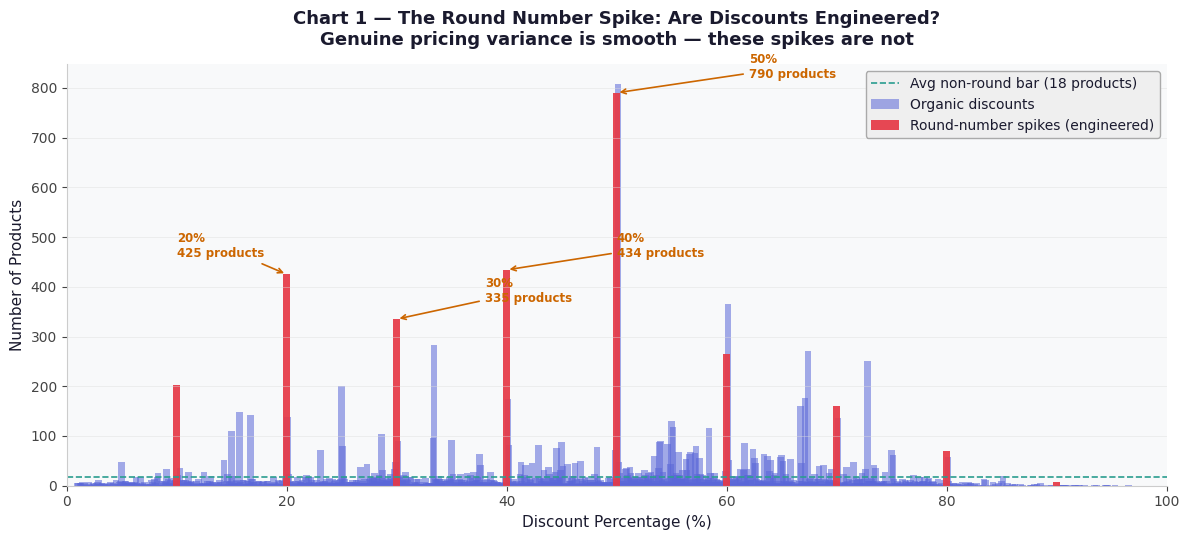

In [78]:
# Chart 1: The Round Number Spike

fig, ax = plt.subplots(figsize=(12, 5.5))

# Non-round bars — organic
ax.bar(non_round_bars["discount_pct"],
       non_round_bars["product_count"],
       width=0.6, color=PURPLE, alpha=0.55,
       label="Organic discounts")

# Round number bars — engineered
ax.bar(round_bars["discount_pct"],
       round_bars["product_count"],
       width=0.6, color=ACCENT, alpha=0.92,
       label="Round-number spikes (engineered)")

# Reference line
avg_non_round = non_round_bars["product_count"].mean()
ax.axhline(y=avg_non_round, color=SAFE, linewidth=1.2,
           linestyle="--",
           label=f"Avg non-round bar ({avg_non_round:.0f} products)")

# Custom offsets for each annotation — moved outside bars
offsets = {
    50: (62, 820),
    40: (50, 460),
    30: (38, 370),
    20: (10, 460),
}

top_4 = round_bars.sort_values("product_count", ascending=False).head(4)

for _, row in top_4.iterrows():
    disc    = int(row["discount_pct"])
    xt, yt  = offsets.get(disc, (disc + 4, row["product_count"] + 40))
    ax.annotate(
        f"{disc}%\n{int(row['product_count'])} products",
        xy=(row["discount_pct"], row["product_count"]),
        xytext=(xt, yt),
        fontsize=8.5, color="#CC6600", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#CC6600", lw=1.2)
    )

# Labels and title
ax.set_xlabel("Discount Percentage (%)", fontsize=11)
ax.set_ylabel("Number of Products", fontsize=11)
ax.set_title(
    "Chart 1 — The Round Number Spike: Are Discounts Engineered?\n"
    "Genuine pricing variance is smooth — these spikes are not",
    fontsize=13, fontweight="bold", pad=14
)
ax.set_xlim(0, 100)
ax.grid(axis="y", zorder=0, alpha=0.5)

ax.legend(facecolor="#EFEFEF", edgecolor="#AAAAAA",
          labelcolor="#1A1A2E", fontsize=10,
          framealpha=1.0)

plt.tight_layout()
plt.savefig("chart1_round_number_spike.png",
            dpi=150, bbox_inches="tight", facecolor="#FFFFFF")
plt.show()

*Red bars mark round-number discounts. The reference line shows the
average height of organic (non-round) bars — spikes above it reveal
engineered pricing.*

In [53]:
# Chart 2 Data Prep

# Using top 10 categories by product count for readability
top_cats = (df_disc["category"]
            .value_counts()
            .head(10)
            .index
            .tolist())

# Filtering inflation index to top 10 categories only
chart2_data = (inflation_index[inflation_index["category"].isin(top_cats)]
               .sort_values("avg_inflation", ascending=True)
               .reset_index(drop=True))

print(chart2_data[["category", "avg_inflation", "confirmed_pct"]])

                     category  avg_inflation  confirmed_pct
0    Beauty and Personal Care           1.45           11.3
1  Home Decor & Festive Needs           1.84           33.7
2                    Footwear           1.96           52.6
3             Home Furnishing           1.97           41.2
4            Kitchen & Dining           2.11           61.2
5                   Computers           2.12           51.1
6                   Jewellery           2.18           46.4
7                    Clothing           2.34           66.7
8                  Automotive           2.50           68.3
9       Mobiles & Accessories           2.51           61.0


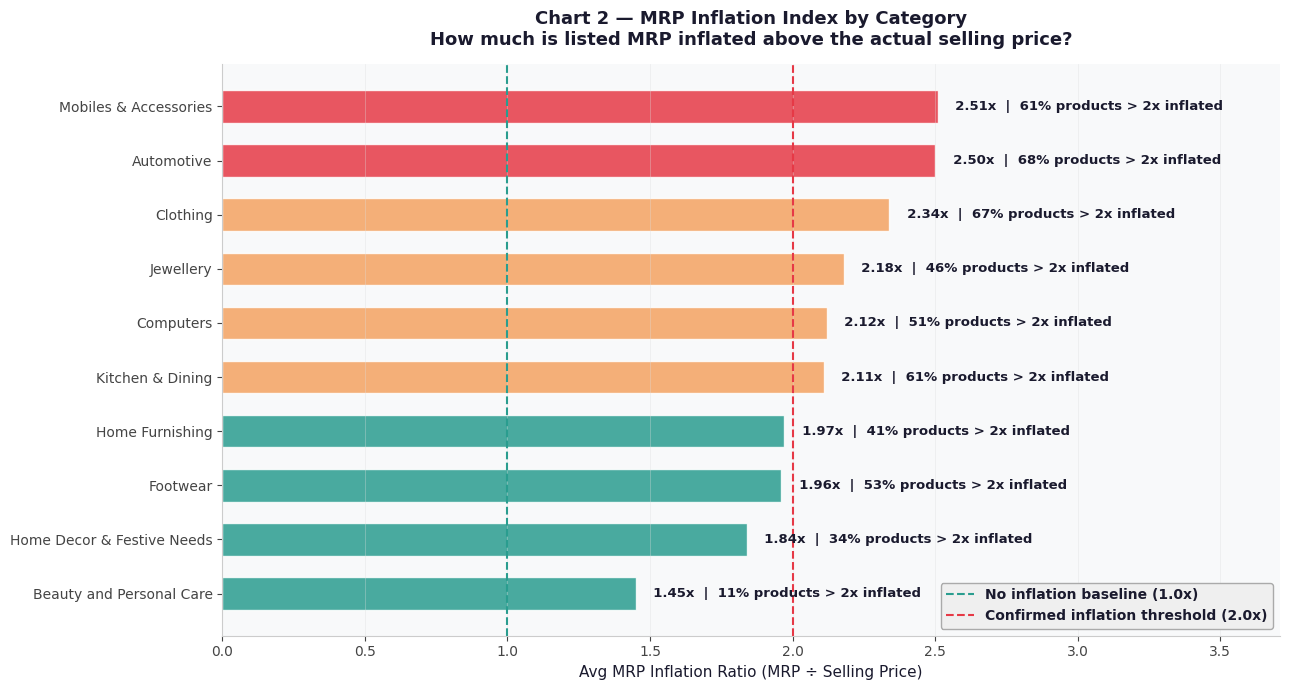

In [76]:
# Chart 2: MRP Inflation Index

fig, ax = plt.subplots(figsize=(13, 7))

# Coloring bars by inflation severity
bar_colors = [
    ACCENT if v >= 2.5 else
    MID    if v >= 2.0 else
    SAFE
    for v in chart2_data["avg_inflation"]
]

ax.barh(chart2_data["category"],
        chart2_data["avg_inflation"],
        color=bar_colors, height=0.6,
        alpha=0.85, edgecolor="#FFFFFF", linewidth=1)

# Labels on each bar — dark color, bold
for i, (_, row) in enumerate(chart2_data.iterrows()):
    ax.text(row["avg_inflation"] + 0.03, i,
            f'  {row["avg_inflation"]:.2f}x  |  '
            f'{row["confirmed_pct"]:.0f}% products > 2x inflated',
            va="center", fontsize=9.5,
            color="#1A1A2E", fontweight="bold")

# Reference lines
ax.axvline(x=1.0, color=SAFE, linewidth=1.5,
           linestyle="--", label="No inflation baseline (1.0x)")
ax.axvline(x=2.0, color=ACCENT, linewidth=1.5,
           linestyle="--", label="Confirmed inflation threshold (2.0x)")

ax.set_xlabel("Avg MRP Inflation Ratio (MRP ÷ Selling Price)", fontsize=11)
ax.set_title(
    "Chart 2 — MRP Inflation Index by Category\n"
    "How much is listed MRP inflated above the actual selling price?",
    fontsize=13, fontweight="bold", pad=14
)
ax.set_xlim(0, chart2_data["avg_inflation"].max() + 1.2)
ax.grid(axis="x", zorder=0, alpha=0.4)
ax.set_facecolor(BG_MID)

ax.legend(facecolor="#EFEFEF", edgecolor="#AAAAAA",
          labelcolor="#1A1A2E", fontsize=10,
          framealpha=1.0,
          prop={"size": 10, "weight": "bold"},
          loc="lower right")

plt.tight_layout()
plt.savefig("chart2_inflation_index.png",
            dpi=150, bbox_inches="tight", facecolor="#FFFFFF")
plt.show()

*Bar length = avg MRP inflation ratio. Label shows % of products
crossing the 2x confirmed inflation threshold. Red bars represent
categories where manipulation is most aggressive.*

In [55]:
# Chart 3 Data Prep

# Filtering phantom summary to top 10 categories by product count
chart3_data = (phantom_summary[phantom_summary["category"].isin(top_cats)]
               .sort_values("avg_phantom_saving", ascending=True)
               .reset_index(drop=True))

# Spliting into two metrics for dual view
print(chart3_data[["category", "avg_phantom_saving", "avg_phantom_pct"]])

                     category  avg_phantom_saving  avg_phantom_pct
0    Beauty and Personal Care              222.23            36.09
1            Kitchen & Dining              301.75            75.60
2                    Clothing              646.21            80.29
3                    Footwear              661.09            73.09
4             Home Furnishing              667.72            70.71
5       Mobiles & Accessories              744.17            76.84
6  Home Decor & Festive Needs              783.44            67.49
7                   Computers              949.70            74.85
8                   Jewellery             1410.58            69.20
9                  Automotive             1565.41            84.00


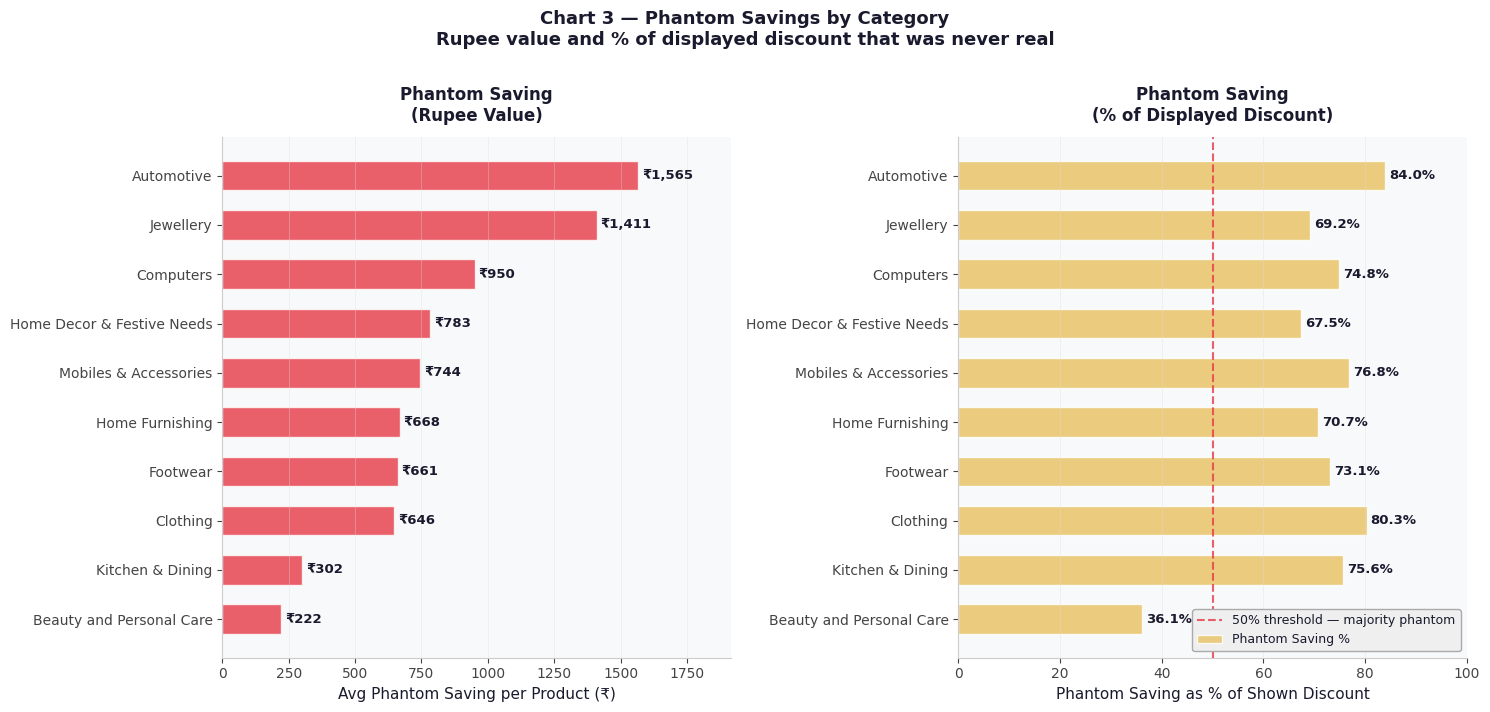

In [74]:
# Chart 3: Phantom Savings

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Left: Avg Phantom Saving in Rupees
ax1.barh(chart3_data["category"],
         chart3_data["avg_phantom_saving"],
         height=0.6, color=ACCENT, alpha=0.80,
         edgecolor="#FFFFFF", linewidth=1)

for i, (_, row) in enumerate(chart3_data.iterrows()):
    ax1.text(row["avg_phantom_saving"] + 15, i,
             f'₹{row["avg_phantom_saving"]:,.0f}',
             va="center", fontsize=9.5,
             color="#1A1A2E", fontweight="bold")

ax1.set_xlabel("Avg Phantom Saving per Product (₹)", fontsize=11)
ax1.set_title("Phantom Saving\n(Rupee Value)",
              fontsize=12, fontweight="bold", pad=12)
ax1.set_xlim(0, chart3_data["avg_phantom_saving"].max() + 350)
ax1.grid(axis="x", zorder=0, alpha=0.4)
ax1.set_facecolor(BG_MID)

# Right: Phantom % of shown discount
ax2.barh(chart3_data["category"],
         chart3_data["avg_phantom_pct"],
         height=0.6, color=GOLD, alpha=0.85,
         edgecolor="#FFFFFF", linewidth=1,
         label="Phantom Saving %")

for i, (_, row) in enumerate(chart3_data.iterrows()):
    ax2.text(row["avg_phantom_pct"] + 0.8, i,
             f'{row["avg_phantom_pct"]:.1f}%',
             va="center", fontsize=9.5,
             color="#1A1A2E", fontweight="bold")

ax2.axvline(x=50, color=ACCENT, linewidth=1.5,
            linestyle="--", alpha=0.8,
            label="50% threshold — majority phantom")

ax2.set_xlabel("Phantom Saving as % of Shown Discount", fontsize=11)
ax2.set_title("Phantom Saving\n(% of Displayed Discount)",
              fontsize=12, fontweight="bold", pad=12)
ax2.set_xlim(0, 100)
ax2.grid(axis="x", zorder=0, alpha=0.4)
ax2.set_facecolor(BG_MID)
ax2.legend(facecolor="#EFEFEF", edgecolor="#AAAAAA",
           labelcolor="#1A1A2E", fontsize=9,
           framealpha=1.0, loc="lower right")

fig.suptitle(
    "Chart 3 — Phantom Savings by Category\n"
    "Rupee value and % of displayed discount that was never real",
    fontsize=13, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig("chart3_phantom_savings.png",
            dpi=150, bbox_inches="tight", facecolor="#FFFFFF")
plt.show()

*Left: Rupee value of savings displayed to consumers that were never real.
Right: What % of the shown discount was phantom. Automotive shows the
highest phantom % (84%) — 84 paise of every ₹1 discount shown was
manufactured. Jewellery carries the highest absolute rupee impact at
scale — ₹1,411 avg phantom saving across 3,284 products.*

In [57]:
# Chart 4 Data Prep

# Quadrant classification for each rated product
HIGH_DISC = 50
HIGH_RAT  = 3.5

def classify_quadrant(row):
    if row["discount_pct"] >= HIGH_DISC and row["rating"] < HIGH_RAT:
        return "Danger Zone (High Discount, Low Quality)"
    elif row["discount_pct"] >= HIGH_DISC and row["rating"] >= HIGH_RAT:
        return "Genuine Deal (High Discount, High Quality)"
    elif row["discount_pct"] < HIGH_DISC and row["rating"] >= HIGH_RAT:
        return "Fair Price (Low Discount, High Quality)"
    else:
        return "Avoid (Low Discount, Low Quality)"

df_rated["quadrant"] = df_rated.apply(classify_quadrant, axis=1)

# Count per quadrant
quadrant_counts = (df_rated["quadrant"]
                   .value_counts()
                   .reset_index()
                   .rename(columns={"index": "quadrant",
                                    "count": "product_count"}))

print(quadrant_counts)
print(f"\nTotal rated products: {len(df_rated):,}")
print(f"\nCorrelation r = {correlation}")

                                     quadrant  product_count
0     Fair Price (Low Discount, High Quality)            534
1  Genuine Deal (High Discount, High Quality)            528
2           Avoid (Low Discount, Low Quality)            250
3    Danger Zone (High Discount, Low Quality)            227

Total rated products: 1,539

Correlation r = 0.016


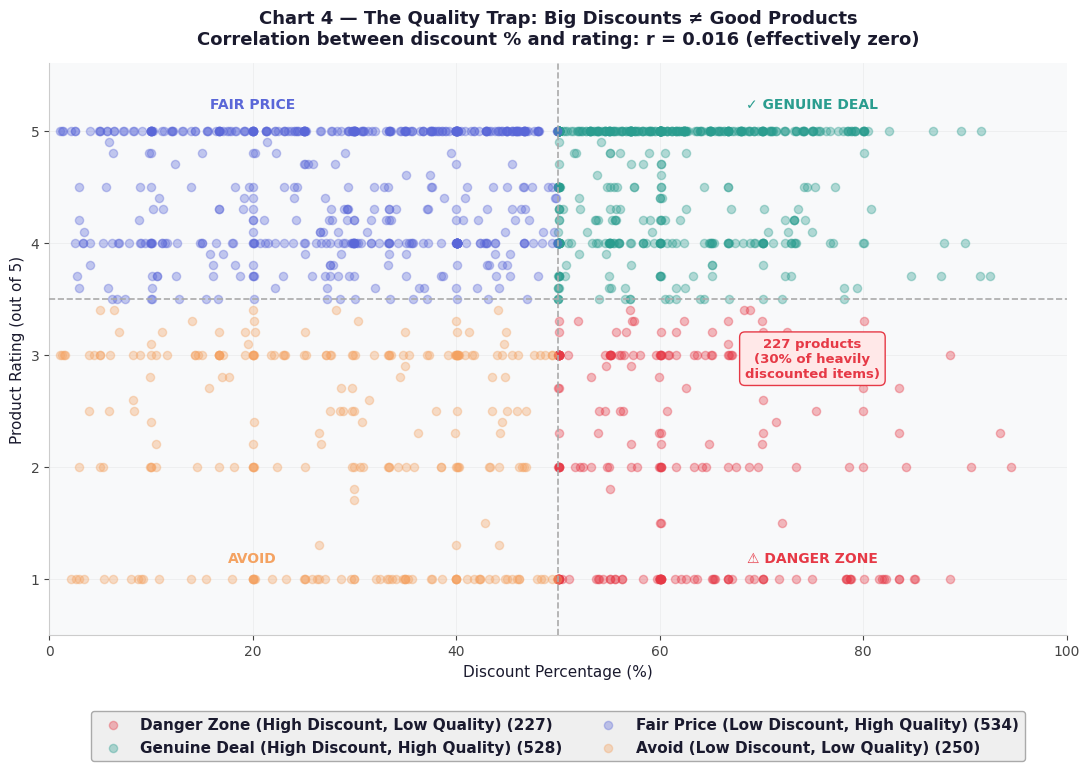

In [73]:
# Chart 4: The Quality Trap

fig, ax = plt.subplots(figsize=(11, 7))

# Coloring and labeling map per quadrant
quadrant_style = {
    "Danger Zone (High Discount, Low Quality)":
        {"color": ACCENT,  "marker": "o", "size": 35},
    "Genuine Deal (High Discount, High Quality)":
        {"color": SAFE,    "marker": "o", "size": 35},
    "Fair Price (Low Discount, High Quality)":
        {"color": PURPLE,  "marker": "o", "size": 35},
    "Avoid (Low Discount, Low Quality)":
        {"color": MID,     "marker": "o", "size": 35},
}

# Plotting each quadrant
for quad, style in quadrant_style.items():
    subset = df_rated[df_rated["quadrant"] == quad]
    count  = len(subset)
    ax.scatter(subset["discount_pct"], subset["rating"],
               color=style["color"], alpha=0.35,
               s=style["size"], zorder=3,
               label=f"{quad} ({count:,})")

# Quadrant divider lines
ax.axvline(x=HIGH_DISC, color="#AAAAAA", linewidth=1.2,
           linestyle="--", zorder=4)
ax.axhline(y=HIGH_RAT,  color="#AAAAAA", linewidth=1.2,
           linestyle="--", zorder=4)

# 4 Quadrants
ax.text(75, 1.15,  "⚠ DANGER ZONE",  fontsize=10,
        color=ACCENT,  fontweight="bold", ha="center",
        transform=ax.transData)
ax.text(20, 1.15,  "AVOID",           fontsize=10,
        color=MID,     fontweight="bold", ha="center")
ax.text(75, 5.2,  "✓ GENUINE DEAL",  fontsize=10,
        color=SAFE,    fontweight="bold", ha="center")
ax.text(20, 5.2,  "FAIR PRICE",      fontsize=10,
        color=PURPLE,  fontweight="bold", ha="center")


# Danger zone count callout
danger_count = len(df_rated[df_rated["quadrant"] ==
                   "Danger Zone (High Discount, Low Quality)"])
total_high   = len(df_rated[df_rated["discount_pct"] >= HIGH_DISC])
danger_pct   = danger_count / total_high * 100

ax.annotate(
    f"{danger_count} products\n({danger_pct:.0f}% of heavily\ndiscounted items)",
    xy=(75, 2.8),
    fontsize=9.5, color=ACCENT, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4",
              facecolor="#FFE8E8", edgecolor=ACCENT),
    ha="center"
)

ax.set_xlabel("Discount Percentage (%)", fontsize=11)
ax.set_ylabel("Product Rating (out of 5)", fontsize=11)
ax.set_xlim(0, 100)
ax.set_ylim(0.5, 5.6)
ax.set_title(
    "Chart 4 — The Quality Trap: Big Discounts ≠ Good Products\n"
    f"Correlation between discount % and rating: r = {correlation} (effectively zero)",
    fontsize=13, fontweight="bold", pad=14
)
ax.grid(zorder=0, alpha=0.4)
ax.legend(facecolor=BG_MID, edgecolor="#CCCCCC",
          labelcolor="#1A1A2E", fontsize=9,
          loc="upper left")

plt.tight_layout()
plt.savefig("chart4_quality_trap.png",
            dpi=150, bbox_inches="tight", facecolor="#FFFFFF")

ax.legend(facecolor="#EFEFEF", edgecolor="#AAAAAA",
          labelcolor="#1A1A2E", fontsize=11,
          loc="upper center",
          bbox_to_anchor=(0.5, -0.12),
          ncol=2,
          framealpha=1.0,
          prop={"size": 11, "weight": "bold"})

plt.savefig("chart4_quality_trap.png",
            dpi=150, bbox_inches="tight",
            facecolor="#FFFFFF")

plt.show()

*Each dot is a rated product. Quadrant lines sit at 50% discount
and 3.5 rating thresholds. r = 0.016 confirms discount % has no predictive power over quality — yet 30% of heavily discounted
products still fall in the Danger Zone.*

In [66]:
# Chart 5 Data Prep

# Use top 10 categories by product count for consistency
chart5_data = (harm_df[harm_df["category"].isin(top_cats)]
               .sort_values("consumer_harm_score", ascending=True)
               .reset_index(drop=True))

print(chart5_data[["category", "consumer_harm_score",
                    "score_round", "score_inflation",
                    "score_phantom"]])

                     category  consumer_harm_score  score_round  \
0    Beauty and Personal Care                 26.9         32.0   
1  Home Decor & Festive Needs                 45.9         29.7   
2            Kitchen & Dining                 48.4          9.2   
3                   Computers                 50.9         17.9   
4                   Jewellery                 57.1         41.2   
5                  Automotive                 59.0          7.0   
6             Home Furnishing                 59.1         60.5   
7       Mobiles & Accessories                 59.9         17.8   
8                    Clothing                 65.4         44.0   
9                    Footwear                 66.0         81.3   

   score_inflation  score_phantom  
0             16.8           35.2  
1             37.2           73.8  
2             51.3           83.8  
3             51.8           82.8  
4             55.0           75.9  
5             71.7           94.1  
6         

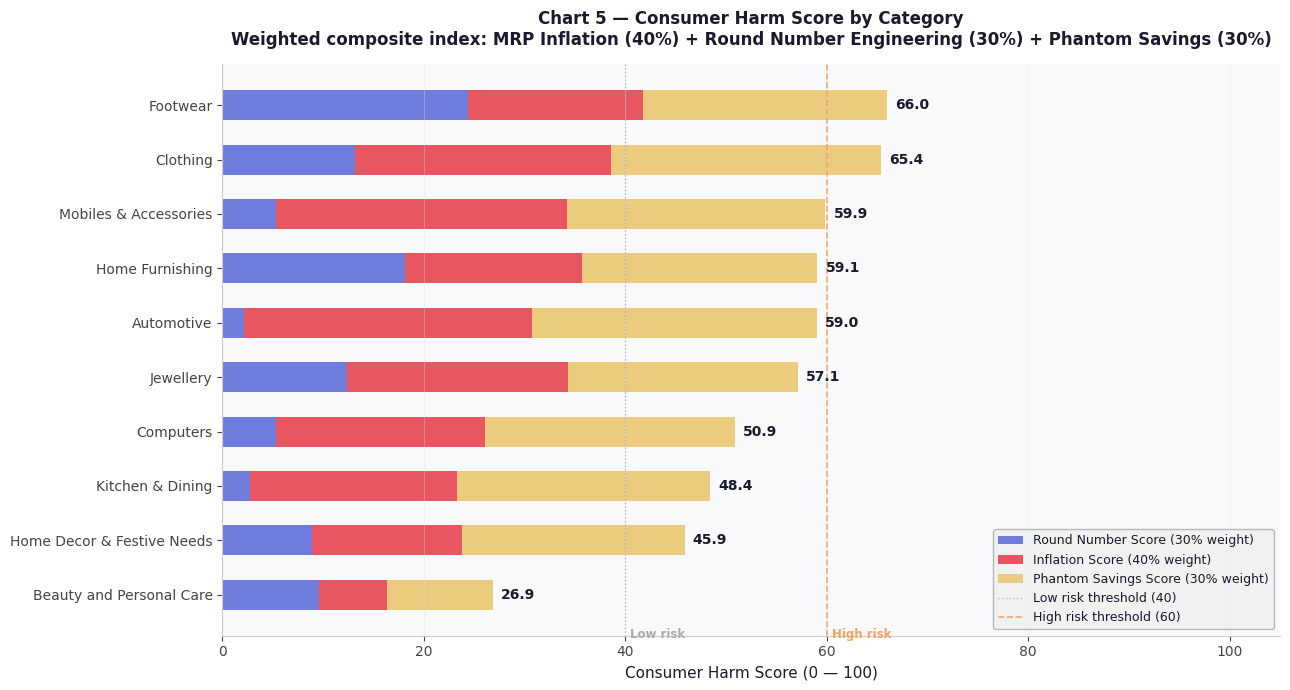

In [70]:
# Chart 5: Consumer Harm Score

fig, ax = plt.subplots(figsize=(13, 7))

# ── Stacked horizontal bars showing score components ──
bars_round = ax.barh(chart5_data["category"],
                     chart5_data["score_round"] * 0.30,
                     height=0.55, color=PURPLE, alpha=0.85,
                     label="Round Number Score (30% weight)")

bars_inflation = ax.barh(chart5_data["category"],
                         chart5_data["score_inflation"] * 0.40,
                         height=0.55, color=ACCENT, alpha=0.85,
                         left=chart5_data["score_round"] * 0.30,
                         label="Inflation Score (40% weight)")

bars_phantom = ax.barh(chart5_data["category"],
                       chart5_data["score_phantom"] * 0.30,
                       height=0.55, color=GOLD, alpha=0.85,
                       left=(chart5_data["score_round"] * 0.30 +
                             chart5_data["score_inflation"] * 0.40),
                       label="Phantom Savings Score (30% weight)")

# Final score label at end of each bar
for i, (_, row) in enumerate(chart5_data.iterrows()):
    ax.text(row["consumer_harm_score"] + 0.8, i,
            f'{row["consumer_harm_score"]:.1f}',
            va="center", fontsize=10,
            color="#1A1A2E", fontweight="bold")

# Threshold lines
ax.axvline(x=40, color="#AAAAAA", linewidth=1,
           linestyle=":", alpha=0.8, label="Low risk threshold (40)")
ax.axvline(x=60, color=MID, linewidth=1.2,
           linestyle="--", alpha=0.9, label="High risk threshold (60)")

# Threshold labels
ax.text(40.5, -0.8, "Low risk", fontsize=8.5,
        color="#AAAAAA", fontweight="bold")
ax.text(60.5, -0.8, "High risk", fontsize=8.5,
        color=MID, fontweight="bold")

ax.set_xlabel("Consumer Harm Score (0 — 100)", fontsize=11)
ax.set_title(
    "Chart 5 — Consumer Harm Score by Category\n"
    "Weighted composite index: MRP Inflation (40%) + "
    "Round Number Engineering (30%) + Phantom Savings (30%)",
    fontsize=12, fontweight="bold", pad=14
)
ax.set_xlim(0, 105)
ax.grid(axis="x", zorder=0, alpha=0.4)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[2:] + handles[:2],
          labels[2:] + labels[:2],
          facecolor="#EFEFEF", edgecolor="#AAAAAA",
          labelcolor="#1A1A2E", fontsize=9,
          loc="lower right")

plt.tight_layout()
plt.savefig("chart5_harm_score.png",
            dpi=150, bbox_inches="tight", facecolor="#FFFFFF")
plt.show()


*Stacked bars show contribution of each component to the final
Consumer Harm Score. Phantom Savings (gold) dominates most categories
— confirming MRP manipulation as the primary driver of consumer harm.
Footwear is a notable exception — harm is driven by round-number
engineering (81.3) and phantom savings (80.7) rather than raw
inflation, suggesting a different manipulation mechanism.
Categories crossing 60 represent highest priority for consumer caution.*

## Conclusion

This analysis investigated 19,922 real Flipkart product listings to determine
whether platform discounts reflect genuine price reductions or systematic
manipulation through MRP inflation.

---

### What We Found

| # | Finding | Result | Signal |
|---|---|---|---|
| 1 | Round-number discount concentration | **15.3%** vs 10% expected | 🔴 1.53x overrepresentation |
| 2 | Avg MRP inflation across platform | **2.3x** selling price | 🔴 MRP is more than double |
| 3 | Phantom savings per product | **₹857 avg** | 🔴 Majority of discount was never real |
| 4 | Total phantom savings (20K products) | **₹1.51 crore** | 🔴 Manufactured consumer perception |
| 5 | Scaled platform estimate | **~₹8,570 crore annually** | 🔴 Across full catalogue |
| 6 | Danger zone products | **227 products** | 🟠 High discount + low quality |
| 7 | Discount-quality correlation | **r = 0.016** | 🟠 Effectively zero predictive power |
| 8 | Highest harm category | **Footwear (66.0)** | 🔴 Tops Consumer Harm Index |

---

### Key Takeaways

**For Consumers:**
Discount percentage is an unreliable signal — both for value and quality.
Always verify price history on tools like Smartprix or PriceSpy before
purchasing, especially during sale events like Big Billion Days.

**For Flipkart:**
84% phantom savings in Automotive and 66.7% confirmed inflation in Clothing
represent significant reputational risk. If consumers systematically discover
discounts are manufactured, platform trust erodes — directly impacting
retention and GMV during high-stakes sale events.

**For Regulators (CCPA):**
The Consumer Harm Score index built in this analysis provides a
category-level framework for prioritising enforcement. Footwear, Clothing,
and Mobiles & Accessories warrant immediate scrutiny given their combination
of high inflation, phantom savings, and consumer reach.

---

### Limitations
- Dataset covers ~20,000 products — a sample of Flipkart's full catalogue
- Ratings available for only 9.2% of products — quality trap analysis
  is directional, not conclusive
- Phantom savings calculation assumes 15% fair margin — actual margins vary
- Scaled platform estimate is illustrative, not audited

---

### What I Would Do With More Data
- Track price history over 90 days to measure pre-sale MRP inflation directly
- Include seller-level analysis — identify repeat offenders
- Expand to Amazon India for cross-platform comparison

In [77]:
from google.colab import files

charts = [
    "chart1_round_number_spike.png",
    "chart2_inflation_index.png",
    "chart3_phantom_savings.png",
    "chart4_quality_trap.png",
    "chart5_harm_score.png",
]

for chart in charts:
    files.download(chart)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>